In [53]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 
  
iris_data = pd.concat([X, y], axis=1)

print(iris_data.head())

# Display feature names
print(X.columns.tolist())

# Display target names
print(y["class"].unique())

   sepal length  sepal width  petal length  petal width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
['sepal length', 'sepal width', 'petal length', 'petal width']
<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


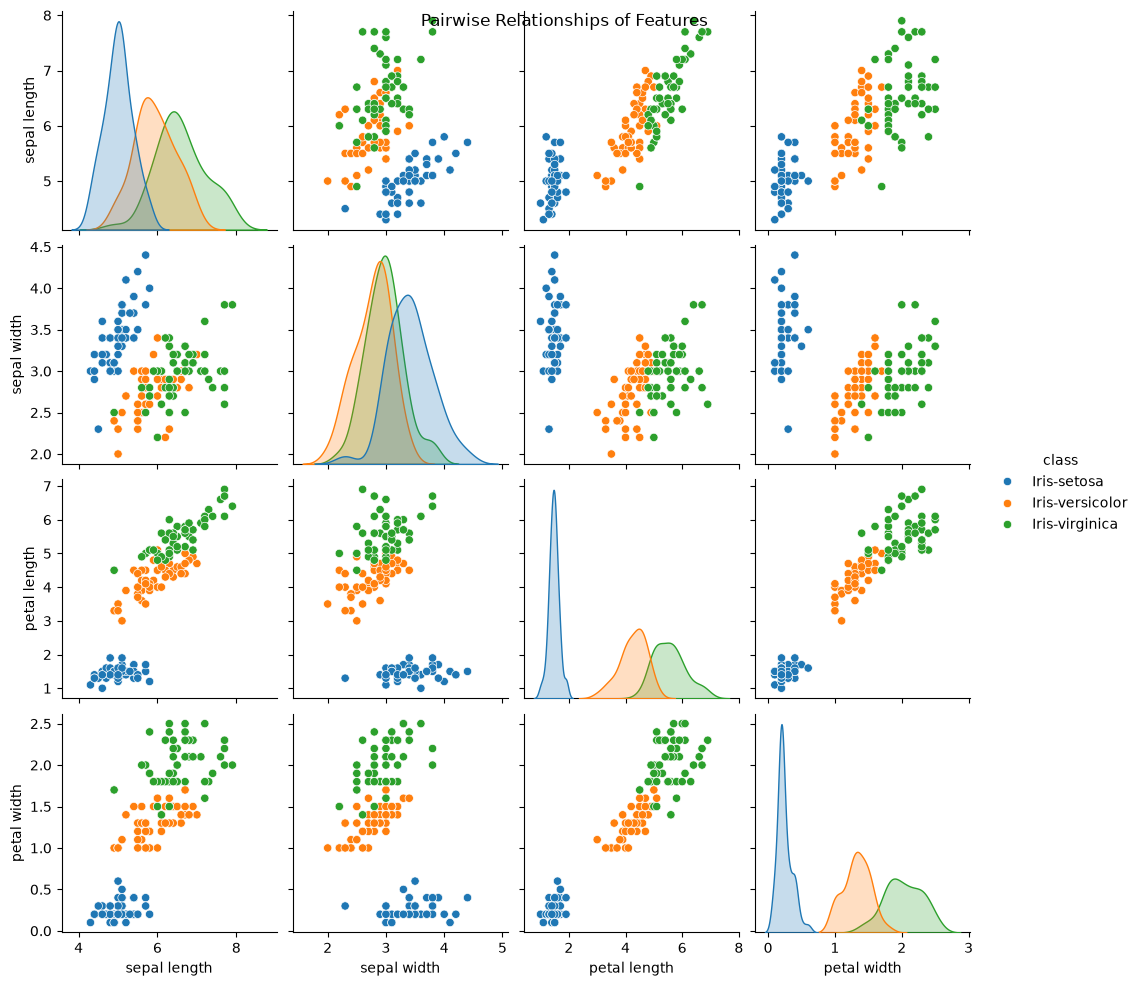

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(iris_data, hue="class")
plt.suptitle("Pairwise Relationships of Features")
plt.show()

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = iris_data.drop("class", axis=1)
Y = iris_data["class"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=y)

In [56]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

dtc_pred = dtc.predict(X_test)
train_pred = dtc.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, dtc_pred)

print(f'Train Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

Train Accuracy: 1.00
Test Accuracy: 0.93


In [57]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/Cellar/graphviz" 

from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(dtc, out_file=None, feature_names = X.columns, class_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
                           filled=True, rounded=True, special_characters=True)
graph=graphviz.Source(dot_data)
graph.render("decision_tree")
graph.view()

'decision_tree.pdf'

In [58]:
from sklearn.tree import DecisionTreeClassifier, export_text

feature_importances = dtc.feature_importances_
feature_importance_summary = sorted(zip(X.columns, feature_importances), key=lambda x: x[1], reverse=True)

print("\nFeature Importances:")
for feature, importance in feature_importance_summary:
    print(f"{feature} : {importance:.4f}")


Feature Importances:
petal width : 0.9060
petal length : 0.0586
sepal width : 0.0292
sepal length : 0.0062


In [59]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10,20,30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

dtcp = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator=dtcp, param_grid=param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.95


In [60]:
best_dtc = grid_search.best_estimator_

best_pred = best_dtc.predict(X_test)
best_accuracy = accuracy_score(y_test, best_pred)

print("Best parameters:", grid_search.best_params_)
print(f"Cross-validation accuracy: {grid_search.best_score_:.2f}")
print(f"Test accuracy: {best_accuracy:.2f}")

Best parameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Cross-validation accuracy: 0.95
Test accuracy: 0.97
